In [ ]:
# NOTE: please move this ipynb file out of the tomography folder to use it.
# this example demostrate how ATS driver get to work with tomography utilities
from ats9371_for_tomography.ats9371 import AlazarTechATS9371
from ats9371_for_tomography.raw_acq_ctrl import RawAcquisitionController
AlazarTechATS9371.find_boards()

[{'system_id': 1,
  'board_id': 1,
  'board_kind': 'ATS9371',
  'max_samples': 4294967294,
  'bits_per_sample': 12}]

In [3]:
# connect to ATS9371
ats_inst = AlazarTechATS9371(name='ATS9371')
acq_ctrl = RawAcquisitionController(
    name='ATS9371_acq', alazar_name='ATS9371'
)

# init clock, must be done before any other clock settings
with ats_inst.syncing():
    ats_inst.clock_source("INTERNAL_CLOCK")
    ats_inst.sample_rate(1_000_000_000)

In [2]:
from matplotlib import pyplot as plt
import numpy as np
from IPython.display import clear_output
def max_record(n_samples, max_mb=84):
    max_bit = max_mb * 1024 * 1024 * 8
    resolution_bit = 12
    return int(max_bit/ resolution_bit / n_samples)
def acq_size_mb(n_records, n_samples):
    resolution_bit = 12
    return (n_records * n_samples * resolution_bit) / 1024 / 1024 / 8

In [ ]:
# config setting
ADC_SAMPLING_RATE = 1_000_000_000 # 1GHz
TRIGGER_DELAY_SAMPLES = 8 * 17 # mutiple of 8
with ats_inst.syncing():
    #### clock setting
    ## option1: internal clock with sampling rate setting
    ats_inst.clock_source("INTERNAL_CLOCK")
    ats_inst.sample_rate(ADC_SAMPLING_RATE)
    ## option2: external clock, sampling rate is the same as clock
    # ats_inst.clock_source("FAST_EXTERNAL_CLOCK")
    ## option3: 10MHz external clock with sampling rate setting
    # ats_inst.clock_source("EXTERNAL_CLOCK_10MHz_REF")
    # ats_inst.external_sample_rate(ADC_SAMPLING_RATE)

    #### trigger setting
    ats_inst.trigger_operation('TRIG_ENGINE_OP_J')
    ats_inst.trigger_engine1("TRIG_ENGINE_J")
    ats_inst.trigger_source1("EXTERNAL")
    # ats_inst.external_trigger_range()
    ats_inst.trigger_slope1("TRIG_SLOPE_POSITIVE")
    ats_inst.trigger_level1(150) # 0~255
    ats_inst.trigger_delay(0)
    ats_inst.trigger_source2("DISABLE")

In [ ]:
# acquisition setting
NUMBER_OF_RECORDS = 10000 # trace per acquisition
NUMBER_OF_SAMPLES = 128*25 # samples per trace, multiple of 128
acq_ctrl.update_acquisitionkwargs(
    samples_per_record = NUMBER_OF_SAMPLES,
    records_per_buffer = NUMBER_OF_RECORDS,
    buffers_per_acquisition = 1,
    allocated_buffers = 1,
)
print('config:')
print(f'-- trigger delay: {TRIGGER_DELAY_SAMPLES} samples')
print(f'-- samples per record: {NUMBER_OF_SAMPLES} samples')
print(f'-- records per aquire: {NUMBER_OF_RECORDS} records')
print(f'-- acq size: {acq_size_mb(NUMBER_OF_RECORDS, NUMBER_OF_SAMPLES):.3f} MB')

config:
-- trigger delay: 136 samples
-- samples per record: 3200 samples
-- records per aquire: 10000 records
-- acq size: 45.776 MB


(8192, 3200)


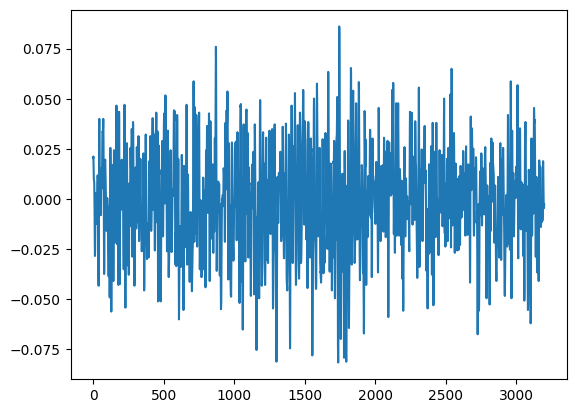

In [12]:
# test acquisition
acq_ctrl.do_acquisition()
chaA, chaB = acq_ctrl.numpy_get_alldata_from_buffer_in_volt()
print(chaA.shape)
plt.plot(chaA[0]) # plot first trace of channel A
plt.show()

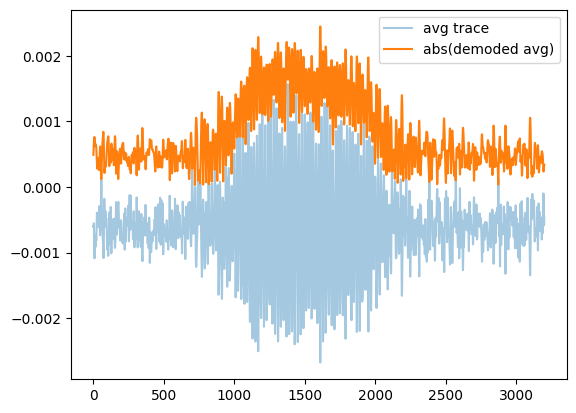

In [ ]:
# test demodulation
from tomography.measurekit import Demodulator
de = Demodulator(fc=50e6, fs=1e9, n_samples=3200)
avg = np.mean(chaA, axis=0)
avg_demoded = de.iq_demod(avg)
plt.plot(avg, label='avg trace', alpha=0.4) #plot avg trace
plt.plot(np.abs(avg_demoded), label='abs(demoded avg)') #plot avg demodulated
plt.legend()
plt.show()

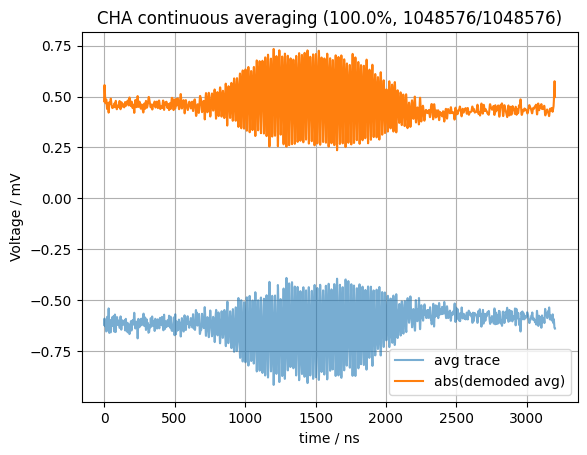

In [ ]:
## example - avg voltage

# acquisition setting
n_shots = 1e6
batch_size = NUMBER_OF_RECORDS
n_batches = n_shots // batch_size
update_interval = n_batches // 20

# initialize processing utils
chaA_mean = np.zeros(NUMBER_OF_SAMPLES)
time_arr = np.arange(NUMBER_OF_SAMPLES) / ADC_SAMPLING_RATE

# start measurement
for n in range(n_batches):
    # aqusition
    acq_ctrl.do_acquisition()
    chaA, chaB = acq_ctrl.numba_get_alldata_from_buffer_in_volt(copy=False)

    # continous averaging
    chaA_mean = (chaA_mean*n + np.mean(chaA, axis=0)) / (n + 1)
    avg_demoded = de.iq_demod(chaA_mean)

    # plotting
    if (n + 1) % update_interval == 0:
        clear_output(wait=True)
        plt.title(f'CHA continuous averaging ({(n + 1)/n_batches* 100:.1f}%, {batch_size*(n + 1)}/{n_shots})')
        plt.plot(1e9*time_arr, 1000*chaA_mean, label='avg trace', alpha=0.6)
        plt.plot(1e9*time_arr, 1000*np.abs(avg_demoded), label='abs(demoded avg)')
        plt.ylabel('Voltage / mV')
        plt.xlabel('time / ns')
        plt.grid(True)
        plt.legend()
        plt.show()

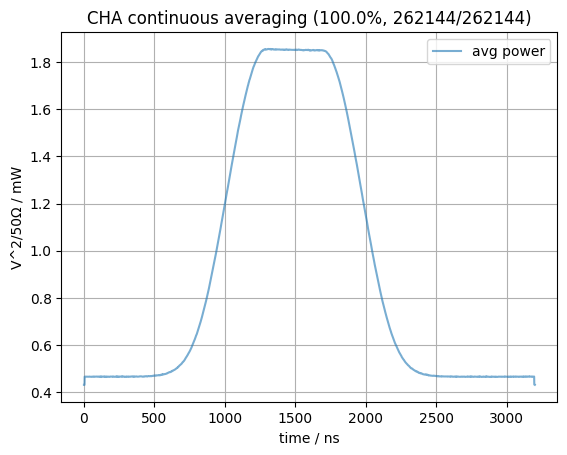

In [ ]:
## example - avg power
# now we need to demod every trace first and compute its abs, then average

# acquisition setting
n_shots = 0.1e6
batch_size = NUMBER_OF_RECORDS
n_batches = n_shots // batch_size
update_interval = n_batches // 20

# initialize processing utils
chaA_power_mean = np.zeros(NUMBER_OF_SAMPLES)
chaA_power_sum = np.zeros(NUMBER_OF_SAMPLES)
time_arr = np.arange(NUMBER_OF_SAMPLES) / ADC_SAMPLING_RATE

# start measurement
for n in range(n_batches):
    # aqusition
    acq_ctrl.do_acquisition()
    chaA, chaB = acq_ctrl.numba_get_alldata_from_buffer_in_volt(copy=False)

    # continous averaging
    for trace in chaA:
        trace_demoded = de.fast_shift_demod(trace)
        chaA_power_sum += np.abs(trace_demoded)
    chaA_power_mean = chaA_power_sum / ((n + 1) * batch_size)

    # plotting
    if (n + 1) % update_interval == 0:
        clear_output(wait=True)
        plt.title(f'CHA continuous averaging ({(n + 1)/n_batches* 100:.1f}%, {batch_size*(n + 1)}/{n_shots})')
        plt.plot(1e9*time_arr, 1000*chaA_power_mean/50, label='avg power', alpha=0.6)
        plt.ylabel('V^2/50Ω / mW')
        plt.xlabel('time / ns')
        plt.grid(True)
        plt.legend()
        plt.show()

# of inner product:  1


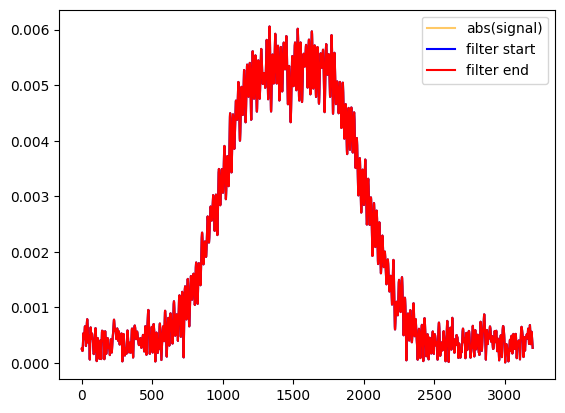

In [ ]:
# temporal mode matching - 1, obtain filter
from tomography.measurekit import TemporalModeMatcher
tmm = TemporalModeMatcher(fs=1e9)

# measure the avraged trace to be tmm filter
# in practice, the number of averaging should be large to make it nice looking
# or even use digital smoothing, or have a theorical curve instead of measured one
acq_ctrl.do_acquisition()
chaA, chaB = acq_ctrl.numpy_get_alldata_from_buffer_in_volt()
avg = np.mean(chaA, axis=0)
avg_demoded = de.iq_demod(avg)
tmm_filter = np.abs(avg_demoded)
tmm.regist_filter(tmm_filter)
tmm.plot_tmm_info(tmm_filter)

In [10]:
# temporal mode matching - 2, transform into time independent mode

# measure the data
acq_ctrl.do_acquisition()
chaA, chaB = acq_ctrl.numpy_get_alldata_from_buffer_in_volt()

# demod it
trace = de.iq_demod(chaA[0])

# then perform tmm
tmm_result, ind = tmm.perform_tmm(trace)
print(f'{tmm_result:.3e}')

8.157e-05+2.562e-05j


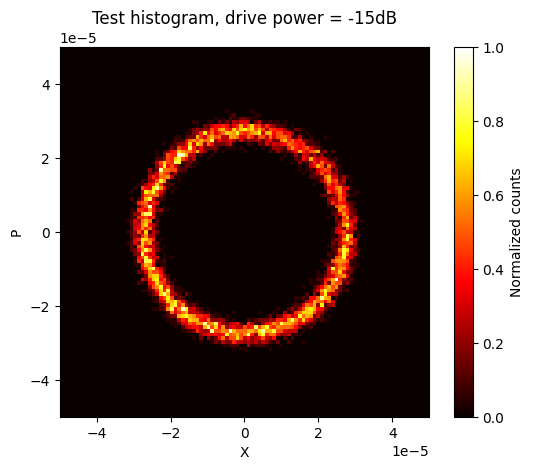

In [ ]:
# example - histogram test (1 aquire)
from tomography.measurekit import Histogram
hist = Histogram(n_row_col=101, max_x_p=50e-6)

# measure trace and accumulate data
acq_ctrl.do_acquisition()
chaA, chaB = acq_ctrl.numpy_get_alldata_from_buffer_in_volt()
for trace in chaA:
    trace_demoded = de.fast_shift_demod(trace)
    tmm_result, ind = tmm.perform_tmm(trace_demoded)
    hist.accumulate_to_histogram(tmm_result)

# plot
hist.plot("Test histogram, drive power = -15dB")

In [ ]:
## example - histogram measurement

# acquisition setting
n_shots = 1e6
batch_size = NUMBER_OF_RECORDS
n_batches = n_shots // batch_size
update_interval = n_batches // 20

# initialize processing utils
hist = Histogram(n_row_col=501, max_x_p=50e-6)

# start measurement
for n in range(n_batches):
    # aqusition
    acq_ctrl.do_acquisition()
    chaA, chaB = acq_ctrl.numba_get_alldata_from_buffer_in_volt(copy=False)

    # tmm -> accumulate
    for trace in chaA:
        trace_demoded = de.fast_shift_demod(trace)
        tmm_result, ind = tmm.perform_tmm(trace_demoded)
        hist.accumulate_to_histogram(tmm_result)

    # plotting
    if (n + 1) % update_interval == 0:
        clear_output(wait=True)
        hist.plot(f'Histogram ({(n + 1)/n_batches* 100:.1f}%, {batch_size*(n + 1)}/{n_shots})')
        plt.show()